# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

C:\Users\Yudha_Putra\AppData\Local\Temp\ipykernel_26392\3947302649.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# **Upload Dataset**

# **Baca Data**

In [3]:
data_train = pd.read_csv("Churn_Modelling.csv")

In [4]:
print(data_train.columns);
print("Jumlah baris:", len(data_train))
print("Jumlah kolom:", len(data_train.columns))

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
Jumlah baris: 10000
Jumlah kolom: 14


# **Lihat Data**

In [5]:
data_train.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **Analisi Deskritif**

## **CreditScore**

In [6]:
# Menghitung rata-rata dan standar deviasi untuk kolom CreditScore
mean_credit_score = data_train['CreditScore'].mean()
std_credit_score = data_train['CreditScore'].std()

# Tampilkan hasil
print(f"Rata-rata CreditScore: {mean_credit_score}")
print(f"Standar Deviasi CreditScore: {std_credit_score}")

Rata-rata CreditScore: 650.5288
Standar Deviasi CreditScore: 96.65329873613035


## **Geography**

In [7]:
# Menghitung persentase distribusi untuk kolom Geography
geography_distribution = data_train['Geography'].value_counts(normalize=True) * 100

# Tampilkan hasil
print("Persentase Distribusi untuk Geography:")
print(geography_distribution)

Persentase Distribusi untuk Geography:
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


## **Gender**

In [8]:
# Menghitung persentase distribusi untuk kolom Gender
gender_distribution = data_train['Gender'].value_counts(normalize=True) * 100

# Tampilkan hasil
print("Persentase Distribusi untuk Gender:")
print(gender_distribution)

Persentase Distribusi untuk Gender:
Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64


## **Age**

In [9]:
# Menghitung rata-rata dan standar deviasi untuk kolom Age
mean_Age = data_train['Age'].mean()
std_Age = data_train['Age'].std()

# Tampilkan hasil
print(f"Rata-rata Age: {mean_Age}")
print(f"Standar Deviasi Age: {std_Age}")

Rata-rata Age: 38.9218
Standar Deviasi Age: 10.487806451704609


## **Tenure**

In [10]:
# Menghitung rata-rata dan standar deviasi untuk kolom Tenure
mean_Tenure = data_train['Tenure'].mean()
std_Tenure = data_train['Tenure'].std()
print(f"Rata-rata Tenure: {mean_Tenure}")
print(f"Standar Deviasi Tenure: {std_Tenure}")

Rata-rata Tenure: 5.0128
Standar Deviasi Tenure: 2.8921743770496837


## **Balance**

In [11]:
# Menghitung rata-rata dan standar deviasi untuk kolom Balance
mean_Balance = data_train['Balance'].mean()
std_Balance = data_train['Balance'].std()
print(f"Rata-rata Balance: {mean_Balance}")
print(f"Standar Deviasi Balance: {std_Balance}")

Rata-rata Balance: 76485.889288
Standar Deviasi Balance: 62397.405202385955


## **NumOfProducts**

In [12]:
# Menghitung rata-rata dan standar deviasi untuk kolom NumOfProducts
mean_NumOfProducts = data_train['NumOfProducts'].mean()
std_NumOfProducts = data_train['NumOfProducts'].std()
print(f"Rata-rata NumOfProducts: {mean_NumOfProducts}")
print(f"Standar Deviasi NumOfProducts: {std_NumOfProducts}")

Rata-rata NumOfProducts: 1.5302
Standar Deviasi NumOfProducts: 0.5816543579989906


## **HasCrCard**

In [13]:
# Menghitung persentase distribusi untuk kolom HasCrCard
hasCrCard_distribution = data_train['HasCrCard'].value_counts(normalize=True) * 100
# Tampilkan hasil
print("Persentase Distribusi untuk HasCrCard:")
print(hasCrCard_distribution)

Persentase Distribusi untuk HasCrCard:
HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64


## **IsActiveMember**

In [14]:
# Menghitung persentase distribusi untuk kolom IsActiveMember
isActiveMember_distribution = data_train['IsActiveMember'].value_counts(normalize=True) * 100

# Tampilkan hasil
print("Persentase Distribusi untuk IsActiveMember:")
print(isActiveMember_distribution)

Persentase Distribusi untuk IsActiveMember:
IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64


## **EstimatedSalary**

In [15]:
# Menghitung rata-rata dan standar deviasi untuk kolom EstimatedSalary
mean_EstimatedSalary = data_train['EstimatedSalary'].mean()
std_EstimatedSalary = data_train['EstimatedSalary'].std()
print(f"Rata-rata EstimatedSalary: {mean_EstimatedSalary}")
print(f"Standar Deviasi EstimatedSalary: {std_EstimatedSalary}")

Rata-rata EstimatedSalary: 100090.239881
Standar Deviasi EstimatedSalary: 57510.49281769816


## **Exited**

In [16]:
# Menghitung persentase distribusi untuk kolom Exited
Exited_distribution = data_train['Exited'].value_counts(normalize=True) * 100

# Tampilkan hasil
print("Persentase Distribusi untuk Exited:")
print(Exited_distribution)

Persentase Distribusi untuk Exited:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


# **Data Preparation**

## **Drop kolom tidak penting**

Drop kolom RowNumber, CustomerId, dan Surname

In [17]:
data_train.drop('RowNumber', axis=1, inplace=True)

In [18]:
data_train.drop('CustomerId', axis=1, inplace=True)

In [19]:
data_train.drop('Surname', axis=1, inplace=True)

## **Hasil Drop**

In [20]:
data_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## **Data praparation Geographyr**

In [21]:
# Cek nilai unik dalam atribut 'Geographyr'
unique_Geography = data_train['Geography'].unique()

# Tampilkan nilai unik
print("Nilai unik dalam atribut 'Geography':")
print(unique_Geography)

Nilai unik dalam atribut 'Geography':
['France' 'Spain' 'Germany']


In [22]:
# Membuat peta penggantian nilai
Geography_map = {'France': 1, 'Spain': 2, 'Germany': 3}

# Mengganti nilai 'Male' dan 'Female' dengan angka dalam kolom 'gender'
data_train['Geography'].replace(Geography_map, inplace=True)


C:\Users\Yudha_Putra\AppData\Local\Temp\ipykernel_26392\4285452245.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['Geography'].replace(Geography_map, inplace=True)
C:\Users\Yudha_Putra\AppData\Local\Temp\ipykernel_26392\4285452245.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d

## **Data Preparation Gender**

In [23]:
# Cek nilai unik dalam atribut 'Gender'
unique_Gender = data_train['Gender'].unique()

# Tampilkan nilai unik
print("Nilai unik dalam atribut 'Gender':")
print(unique_Gender)

Nilai unik dalam atribut 'Gender':
['Female' 'Male']


In [24]:
# Membuat peta penggantian nilai
Gender_map = {'Male': 1, 'Female': 2}

# Mengganti nilai 'Male' dan 'Female' dengan angka dalam kolom 'Gender'
data_train['Gender'].replace(Gender_map, inplace=True)


C:\Users\Yudha_Putra\AppData\Local\Temp\ipykernel_26392\2557254845.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['Gender'].replace(Gender_map, inplace=True)
C:\Users\Yudha_Putra\AppData\Local\Temp\ipykernel_26392\2557254845.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_tr

## **Hasil data preparation**

In [25]:
data_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,1,2,42,2,0.00,1,1,1,101348.88,1
1,608,2,2,41,1,83807.86,1,0,1,112542.58,0
2,502,1,2,42,8,159660.80,3,1,0,113931.57,1
3,699,1,2,39,1,0.00,2,0,0,93826.63,0
4,850,2,2,43,2,125510.82,1,1,1,79084.10,0


In [26]:
from scipy.stats import skew, kurtosis
# Atribut yang ingin dihitung statistik deskriptifnya
attributes = ['CreditScore', 'Geography',	'Gender',	'Age', 'Tenure', 'Balance',	'NumOfProducts',
              'HasCrCard',	'IsActiveMember',	'EstimatedSalary', 'Exited']
attributes_label = ['CS', 'GEO',	'GEN',	'AGE', 'TEN', 'BLC',	'NOP',
              'HCC',	'IAM',	'ES', 'Exited']


# List kosong untuk menyimpan hasil
mean_values = []
std_values = []
skewness_values = []
kurtosis_values = []
max_values = []
min_values = []

# Loop untuk menghitung statistik deskriptif
for attribute in attributes:
    mean_value = data_train[attribute].mean()
    std_value = data_train[attribute].std()
    skewness_value = skew(data_train[attribute])
    kurtosis_value = kurtosis(data_train[attribute])
    max_value = data_train[attribute].max()
    min_value = data_train[attribute].min()

    mean_values.append(round(mean_value, 2))
    std_values.append(round(std_value, 2))
    skewness_values.append(round(skewness_value, 2))
    kurtosis_values.append(round(kurtosis_value, 2))
    max_values.append(max_value)
    min_values.append(min_value)

# Membuat DataFrame untuk statistik deskriptif
df_statistik = pd.DataFrame({
    'Atribut': attributes,
    'Min': min_values,
    'Max': max_values,
    'Mean': mean_values,
    'Std Dev': std_values,
    'Skewness': skewness_values,
    'Kurtosis': kurtosis_values
})

print("Statistik Deskriptif:")
print(df_statistik)


Statistik Deskriptif:
            Atribut     Min        Max       Mean   Std Dev  Skewness  \
0       CreditScore  350.00     850.00     650.53     96.65     -0.07   
1         Geography    1.00       3.00       1.75      0.83      0.49   
2            Gender    1.00       2.00       1.45      0.50      0.18   
3               Age   18.00      92.00      38.92     10.49      1.01   
4            Tenure    0.00      10.00       5.01      2.89      0.01   
5           Balance    0.00  250898.09   76485.89  62397.41     -0.14   
6     NumOfProducts    1.00       4.00       1.53      0.58      0.75   
7         HasCrCard    0.00       1.00       0.71      0.46     -0.90   
8    IsActiveMember    0.00       1.00       0.52      0.50     -0.06   
9   EstimatedSalary   11.58  199992.48  100090.24  57510.49      0.00   
10           Exited    0.00       1.00       0.20      0.40      1.47   

    Kurtosis  
0      -0.43  
1      -1.37  
2      -1.97  
3       1.39  
4      -1.17  
5      -1.4

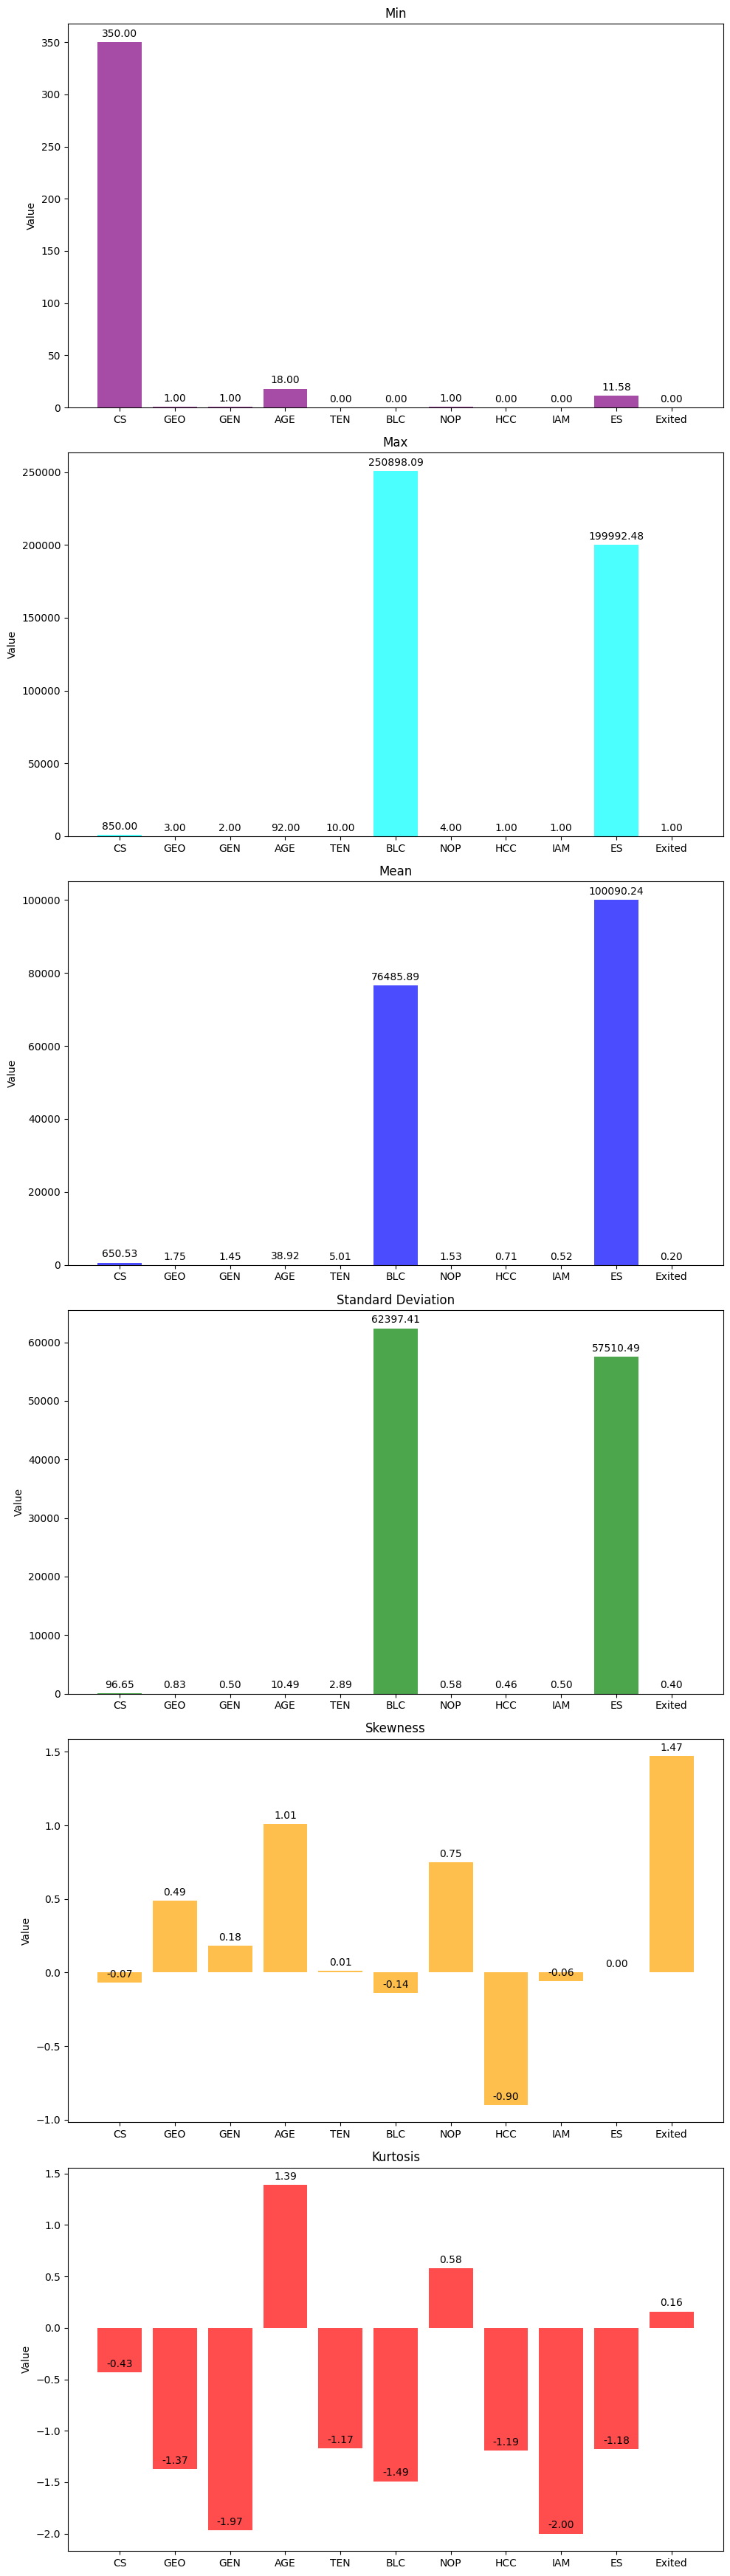

In [27]:
# Membuat DataFrame untuk statistik deskriptif dengan urutan kolom yang diinginkan
df_statistik = pd.DataFrame({
    'Atribut': attributes_label,
    'Min': min_values,
    'Max': max_values,
    'Mean': mean_values,
    'Std Dev': std_values,
    'Skewness': skewness_values,
    'Kurtosis': kurtosis_values
}, columns=['Atribut', 'Min', 'Max', 'Mean', 'Std Dev', 'Skewness', 'Kurtosis'])

# Set up figure dan axis
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(10, 35))
fig.subplots_adjust(top=0.95, bottom=0.1, left=0.1, right=0.95, hspace=0.3, wspace=0.2)

# Plot Min
bars_min = axes[0].bar(df_statistik['Atribut'], df_statistik['Min'], color='purple', alpha=0.7)
axes[0].set_title('Min')
axes[0].set_ylabel('Value')

# Annotate Min values
for bar, min_val in zip(bars_min, df_statistik['Min']):
    axes[0].annotate(f'{min_val:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot Max
bars_max = axes[1].bar(df_statistik['Atribut'], df_statistik['Max'], color='cyan', alpha=0.7)
axes[1].set_title('Max')
axes[1].set_ylabel('Value')

# Annotate Max values
for bar, max_val in zip(bars_max, df_statistik['Max']):
    axes[1].annotate(f'{max_val:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot Mean
bars_mean = axes[2].bar(df_statistik['Atribut'], df_statistik['Mean'], color='blue', alpha=0.7)
axes[2].set_title('Mean')
axes[2].set_ylabel('Value')

# Annotate Mean values
for bar, mean_val in zip(bars_mean, df_statistik['Mean']):
    axes[2].annotate(f'{mean_val:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot Standard Deviation
bars_std = axes[3].bar(df_statistik['Atribut'], df_statistik['Std Dev'], color='green', alpha=0.7)
axes[3].set_title('Standard Deviation')
axes[3].set_ylabel('Value')

# Annotate Std Dev values
for bar, std_val in zip(bars_std, df_statistik['Std Dev']):
    axes[3].annotate(f'{std_val:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot Skewness
bars_skew = axes[4].bar(df_statistik['Atribut'], df_statistik['Skewness'], color='orange', alpha=0.7)
axes[4].set_title('Skewness')
axes[4].set_ylabel('Value')

# Annotate Skewness values
for bar, skew_val in zip(bars_skew, df_statistik['Skewness']):
    axes[4].annotate(f'{skew_val:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot Kurtosis
bars_kurt = axes[5].bar(df_statistik['Atribut'], df_statistik['Kurtosis'], color='red', alpha=0.7)
axes[5].set_title('Kurtosis')
axes[5].set_ylabel('Value')

# Annotate Kurtosis values
for bar, kurt_val in zip(bars_kurt, df_statistik['Kurtosis']):
    axes[5].annotate(f'{kurt_val:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom')

# Adjust layout
plt.tight_layout()

# Menampilkan plot
plt.show()

# **Split Train dan Test**

In [28]:
# label
label = data_train['Exited']
data_train.drop('Exited', axis=1, inplace=True)
label = np.array(label)
data_train = np.array(data_train)

In [29]:
label

array([1, 0, 1, ..., 1, 1, 0], dtype=int64)

In [30]:
data_train


array([[6.1900000e+02, 1.0000000e+00, 2.0000000e+00, ..., 1.0000000e+00,
        1.0000000e+00, 1.0134888e+05],
       [6.0800000e+02, 2.0000000e+00, 2.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 1.1254258e+05],
       [5.0200000e+02, 1.0000000e+00, 2.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 1.1393157e+05],
       ...,
       [7.0900000e+02, 1.0000000e+00, 2.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 4.2085580e+04],
       [7.7200000e+02, 3.0000000e+00, 1.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 9.2888520e+04],
       [7.9200000e+02, 1.0000000e+00, 2.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 3.8190780e+04]])

# **Normalisasi Dataset**

In [31]:
max_vals = np.max(data_train, 0)
data_train = data_train / max_vals

In [32]:
data_train

array([[0.72823529, 0.33333333, 1.        , ..., 1.        , 1.        ,
        0.50676345],
       [0.71529412, 0.66666667, 1.        , ..., 0.        , 1.        ,
        0.56273406],
       [0.59058824, 0.33333333, 1.        , ..., 1.        , 0.        ,
        0.56967927],
       ...,
       [0.83411765, 0.33333333, 1.        , ..., 0.        , 1.        ,
        0.21043581],
       [0.90823529, 1.        , 0.5       , ..., 1.        , 0.        ,
        0.46446006],
       [0.93176471, 0.33333333, 1.        , ..., 1.        , 0.        ,
        0.19096108]])

In [33]:
X_train, x_test, Y_train, y_test = train_test_split(data_train, label, test_size=0.3, random_state = 42);
print('Train shape:', X_train.shape)
print('Test shape:', x_test.shape)

Train shape: (7000, 10)
Test shape: (3000, 10)


# **BUILD MULTILAYER PRECEPTRON MODEL**

## **Inisialisasi parameter dan hyperparameter**

In [34]:
input_dim = X_train.shape[1]  # jumlah atribut
output_dim = 1  # karena binary

# hyperparameter
lr = 0.001
optimizer = Adam(learning_rate=lr)
batch_size = 30 # banyak data yang dipelajari
epochs = 200 # berapa kali taining

## **Build Model**

In [35]:
model = Sequential([
    Dense(128, input_shape=(input_dim,), activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(output_dim, activation='sigmoid'),
], name='tabularnet')

c:\Users\Yudha_Putra\anaconda3\envs\env_data\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Visualisasi Model**

In [36]:
plot_model(model,
           to_file=model.name+'.png',
           show_shapes=True,
           show_layer_names=False,
           rankdir='LR',
           dpi=70
           )

You must install pydot (`pip install pydot`) for `plot_model` to work.


## **Compile Model**

In [37]:
model.summary()

Model: "tabularnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,225 (47.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [38]:
model.compile(optimizer=optimizer,loss='binary_crossentropy', metrics=['accuracy'])

# **TRAIN MODEL**

In [39]:
history = model.fit(X_train, Y_train,
                    validation_data=(x_test, y_test),
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=2) # 0, 1, 2 gaada jalan , ada jalan, hasil

Epoch 1/200
234/234 - 4s - 18ms/step - accuracy: 0.6441 - loss: 0.7430 - val_accuracy: 0.8053 - val_loss: 0.4836
Epoch 2/200
234/234 - 1s - 3ms/step - accuracy: 0.7433 - loss: 0.5675 - val_accuracy: 0.8090 - val_loss: 0.4457
Epoch 3/200
234/234 - 1s - 3ms/step - accuracy: 0.7713 - loss: 0.5165 - val_accuracy: 0.8207 - val_loss: 0.4244
Epoch 4/200
234/234 - 1s - 3ms/step - accuracy: 0.7910 - loss: 0.4930 - val_accuracy: 0.8247 - val_loss: 0.4168
Epoch 5/200
234/234 - 1s - 4ms/step - accuracy: 0.7954 - loss: 0.4814 - val_accuracy: 0.8273 - val_loss: 0.4111
Epoch 6/200
234/234 - 1s - 4ms/step - accuracy: 0.7963 - loss: 0.4651 - val_accuracy: 0.8303 - val_loss: 0.4056
Epoch 7/200
234/234 - 1s - 4ms/step - accuracy: 0.8021 - loss: 0.4551 - val_accuracy: 0.8323 - val_loss: 0.4045
Epoch 8/200
234/234 - 1s - 3ms/step - accuracy: 0.8023 - loss: 0.4499 - val_accuracy: 0.8350 - val_loss: 0.3984
Epoch 9/200
234/234 - 1s - 3ms/step - accuracy: 0.8099 - loss: 0.4423 - val_accuracy: 0.8377 - val_loss

## **Visualisasi Training Result**

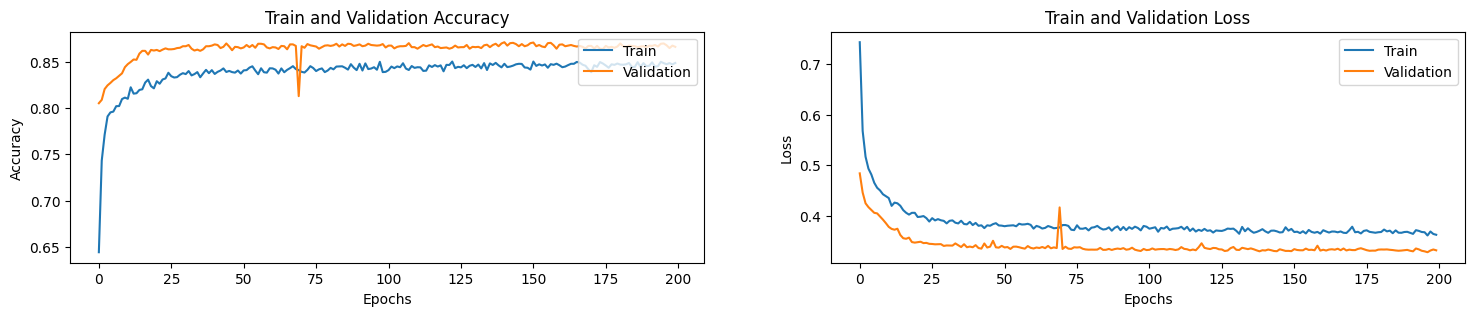

In [40]:
fig, ax = plt.subplots(1,2,figsize=(18,3))
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title("Train and Validation Accuracy")
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(['Train', 'Validation'], loc='upper right')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title("Train and Validation Loss")
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(['Train', 'Validation'], loc='upper right')
plt.show()

## **Calculate Accuracy**

In [41]:
# Predict the data test
output = model.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [42]:
output

array([[0.04615962],
       [0.02925992],
       [0.17669289],
       ...,
       [0.03792486],
       [0.01679949],
       [0.15750405]], dtype=float32)

In [43]:
true_positive = 0;
false_positive = 0;
true_negative = 0;
false_negative = 0;
for (real, pred) in zip(y_test, output):
  if pred > 0.3:
    if real == 1:
      true_positive += 1
    else:
      false_positive += 1
  else:
    if real == 1:
      false_negative += 1
    else:
      true_negative += 1

## **Precision dan Recall**

In [44]:
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
print("Precisoin:", precision)
print("Recall   :", recall)

Precisoin: 0.5883280757097792
Recall   : 0.6386986301369864


## **Akurasi**

In [45]:
akurasi = (true_positive + true_negative) / output.shape[0]
print ('Akurasi:', akurasi);

Akurasi: 0.8426666666666667


# **Simpan Model**

In [46]:
from keras.models import load_model

In [47]:
model.save('model.h5')

In [48]:
import pickle

In [49]:
model.fit(X, y)

NameError: name 'X' is not defined